# 1. EDA Setup and Data Loading

## Purpose

This notebook performs exploratory data analysis (EDA) on the cleaned Rossmann Store Sales datasets.

The objective is to understand the main distributions, relationships, group differences, and temporal patterns in the data before feature engineering and predictive modelling.

This first section loads the processed datasets, restores the required data types, prepares the output directory for figures, and establishes a consistent visualization style for the analysis.

## Input

The following processed datasets are used:

- `data/processed/train_clean.csv`
- `data/processed/store_clean.csv`

These files were created and validated in the previous cleaning stage.

## Output

No analytical result or figure is generated in this section.

The following objects are prepared in memory:

- `train`: cleaned daily store sales data;
- `store`: cleaned store-level information.

The following directory is also prepared for later figures:

- `outputs/figures/`

All figures generated during EDA will be displayed directly in the notebook and important figures will also be saved as PNG files for later reporting.

## Method

The processed CSV files are loaded using Pandas.

Because CSV does not preserve Pandas data-type metadata, the required string, nullable numeric, and datetime representations are explicitly restored during loading.

Matplotlib is used as the primary visualization library.

A consistent scientific-style visualization configuration is established using:

- a white background;
- subtle grid lines;
- low-saturation pastel colours;
- dark grey text for high readability;
- restrained borders and visual decoration.

The colour palette is used consistently throughout the notebook, but chart type and colour assignment will be determined by the analytical purpose of each figure rather than by appearance alone.

## Principle

EDA should present the underlying data as clearly and faithfully as possible.

Visual design is therefore treated as a communication tool rather than a decorative objective.

The visual style will remain consistent across figures, while the type of chart, data aggregation, axis scale, and highlighting strategy will be selected according to the statistical question being examined.

## Evaluation Criteria

The setup is considered successful if:

1. both processed datasets are loaded successfully;
2. their expected dimensions are preserved;
3. `Date` is restored as a datetime variable;
4. the intended nullable and string data types are restored;
5. the figures directory exists;
6. the visualization configuration is successfully initialized.

No statistical interpretation is performed in this section.

In [1]:
# Load the cleaned datasets and initialize the EDA visualization environment.

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Define project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

TRAIN_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "train_clean.csv"
)

STORE_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "store_clean.csv"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. Load the cleaned training dataset
# ------------------------------------------------------------

train = pd.read_csv(
    TRAIN_PATH,
    dtype={
        "StateHoliday": "string"
    }
)

train["Date"] = pd.to_datetime(
    train["Date"],
    format="%Y-%m-%d",
    errors="raise"
)


# ------------------------------------------------------------
# 3. Load the cleaned store dataset
# ------------------------------------------------------------

store = pd.read_csv(
    STORE_PATH,
    dtype={
        "CompetitionDistance": "Float64",
        "CompetitionOpenSinceMonth": "Int64",
        "CompetitionOpenSinceYear": "Int64",
        "Promo2SinceWeek": "Int64",
        "Promo2SinceYear": "Int64",
        "PromoInterval": "string"
    }
)


# ------------------------------------------------------------
# 4. Define the project colour palette
# ------------------------------------------------------------

PASTEL_BLUE = "#AFCBFF"
PASTEL_GREEN = "#B7E4C7"
PASTEL_PURPLE = "#D9C2F0"
PASTEL_YELLOW = "#F6E7A1"
PASTEL_PINK = "#F7C6D9"
PASTEL_ORANGE = "#F7D6A3"

DARK_GREY = "#4A4A4A"
MID_GREY = "#7A7A7A"
LIGHT_GREY = "#EAEAEA"

PASTEL_PALETTE = [
    PASTEL_BLUE,
    PASTEL_GREEN,
    PASTEL_PURPLE,
    PASTEL_YELLOW,
    PASTEL_PINK,
    PASTEL_ORANGE
]


# ------------------------------------------------------------
# 5. Configure the default Matplotlib appearance
# ------------------------------------------------------------

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 120,

    "figure.facecolor": "white",
    "axes.facecolor": "white",

    "axes.edgecolor": MID_GREY,
    "axes.labelcolor": DARK_GREY,
    "axes.titlecolor": DARK_GREY,

    "axes.grid": True,
    "grid.color": LIGHT_GREY,
    "grid.linewidth": 0.7,
    "grid.alpha": 0.7,

    "xtick.color": DARK_GREY,
    "ytick.color": DARK_GREY,

    "text.color": DARK_GREY,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,

    "legend.frameon": False
})


# ------------------------------------------------------------
# 6. Validate the EDA setup
# ------------------------------------------------------------

eda_setup = pd.DataFrame({
    "Item": [
        "train rows",
        "train columns",
        "store rows",
        "store columns",
        "Date dtype",
        "StateHoliday dtype",
        "Figures directory exists"
    ],
    "Result": [
        train.shape[0],
        train.shape[1],
        store.shape[0],
        store.shape[1],
        str(train["Date"].dtype),
        str(train["StateHoliday"].dtype),
        FIGURES_DIR.exists()
    ]
})

display(eda_setup)

,Item,Result
0,train rows,1017209
1,train columns,9
2,store rows,1115
3,store columns,10
4,Date dtype,datetime64[us]
5,StateHoliday dtype,string
6,Figures directory exists,True


# 2. Descriptive Statistics of Core Daily Variables

## Purpose

This section summarizes the central tendency, variability, and distribution range of the two core daily numerical variables:

- `Sales`
- `Customers`

Because closed stores naturally have zero sales and zero customers, descriptive statistics are calculated for two analytical scopes:

1. all daily records;
2. operating-day records where `Open = 1`.

This distinction prevents structural zeros caused by store closure from being interpreted as ordinary low-sales observations.

## Input

This section uses the cleaned daily dataset:

- `train`

No additional file is read.

The main variables are:

- `Sales`
- `Customers`
- `Open`

## Statistical Measures

### Arithmetic Mean

The arithmetic mean represents the average value of a variable.

$$
\boxed{
\bar{x}
=
\frac{1}{n}
\sum_{i=1}^{n} x_i
}
$$

where:

- $x_i$ is the value of observation $i$;
- $n$ is the number of valid observations;
- $\bar{x}$ is the arithmetic mean.

The calculation can also be written as:

$$
\boxed{
\bar{x}
=
\frac{x_1+x_2+\cdots+x_n}{n}
}
$$

---

### Median

The median is the middle value after the observations are sorted from smallest to largest.

For an odd number of observations:

$$
\boxed{
\tilde{x}
=
x_{\left(\frac{n+1}{2}\right)}
}
$$

For an even number of observations:

$$
\boxed{
\tilde{x}
=
\frac{
x_{\left(\frac{n}{2}\right)}
+
x_{\left(\frac{n}{2}+1\right)}
}{2}
}
$$

The median is less sensitive to extreme values than the arithmetic mean.

---

### Sample Variance

Variance measures the average squared dispersion of observations around the mean.

The sample variance is calculated as:

$$
\boxed{
s^2
=
\frac{
\sum_{i=1}^{n}
(x_i-\bar{x})^2
}{
n-1
}
}
$$

where:

- $x_i-\bar{x}$ is the deviation of each observation from the mean;
- the deviations are squared so that positive and negative deviations do not cancel;
- $n-1$ is used for the sample variance.

Pandas calculates variance using this sample-variance definition by default when `ddof=1`.

---

### Standard Deviation

The standard deviation is the square root of the variance:

$$
\boxed{
s
=
\sqrt{s^2}
}
$$

Unlike variance, standard deviation is expressed in the same unit as the original variable and is therefore easier to interpret directly.

---

### Quartiles and Interquartile Range

The first and third quartiles are:

$$
\boxed{
Q_1=P_{25}
}
$$

$$
\boxed{
Q_3=P_{75}
}
$$

The interquartile range is:

$$
\boxed{
IQR
=
Q_3-Q_1
}
$$

The IQR describes the range containing the middle 50% of observations and is relatively resistant to extreme values.

## Output

Three outputs are produced:

1. a record-status summary showing the number and percentage of open and closed daily observations;
2. a descriptive-statistics table for `Sales` and `Customers`;
3. a calculation audit for operating-day `Sales` showing the intermediate quantities used to obtain the main statistics.

The descriptive-statistics table contains:

- Count
- Mean
- Median
- Variance
- Standard Deviation
- Minimum
- First Quartile
- Third Quartile
- IQR
- Maximum

No figure is generated in this section.

## Method

Statistics are calculated separately for:

- all daily observations;
- observations where `Open = 1`.

Missing values are excluded from each calculation if present.

Variance and standard deviation are calculated using the sample definitions with:

`ddof = 1`

The quartiles are calculated using Pandas' quantile method.

The calculation audit explicitly reconstructs the mean, variance, and other statistics for operating-day `Sales` rather than relying only on a single summary function.

## Principle

Different statistics describe different properties of a distribution.

The mean is sensitive to extreme values, whereas the median represents the central ordered observation and is more robust to highly skewed distributions.

Variance and standard deviation measure dispersion, while quartiles and the IQR describe the central spread without being strongly influenced by extreme observations.

For this dataset, separating closed-store records from operating-day records is particularly important because zero sales caused by store closure have a different meaning from low sales during normal operation.

## Evaluation Criteria

The descriptive analysis is considered successful if:

1. all records are correctly classified as open or closed;
2. summary statistics are calculated for both analytical scopes;
3. mean and median are calculated independently;
4. variance uses the stated sample-variance definition;
5. the standard deviation is consistent with the square root of the variance;
6. the IQR equals $Q_3-Q_1$;
7. the calculation audit reproduces the corresponding summary statistics.

The results will subsequently be used to determine the most appropriate visualization strategy for the distributions of `Sales` and `Customers`.

In [2]:
# Calculate descriptive statistics for the core daily variables.

# ------------------------------------------------------------
# 1. Summarize open and closed daily records
# ------------------------------------------------------------

total_records = len(train)

open_records = int(
    (train["Open"] == 1).sum()
)

closed_records = int(
    (train["Open"] == 0).sum()
)

record_status_summary = pd.DataFrame({
    "Store Status": [
        "All records",
        "Open = 1",
        "Open = 0"
    ],
    "Records": [
        total_records,
        open_records,
        closed_records
    ],
    "Percentage (%)": [
        100.0,
        open_records / total_records * 100,
        closed_records / total_records * 100
    ]
})

print("Daily record status:")
display(
    record_status_summary.style.format({
        "Records": "{:,}",
        "Percentage (%)": "{:.2f}"
    })
)


# ------------------------------------------------------------
# 2. Create the operating-day subset
# ------------------------------------------------------------

train_open = train.loc[
    train["Open"] == 1
].copy()


# ------------------------------------------------------------
# 3. Define a reusable descriptive-statistics function
# ------------------------------------------------------------

def calculate_descriptive_statistics(
    series,
    scope,
    variable
):
    values = (
        series
        .dropna()
        .astype(float)
    )

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    return {
        "Scope": scope,
        "Variable": variable,
        "Count": int(values.count()),
        "Mean": values.mean(),
        "Median": values.median(),
        "Variance": values.var(ddof=1),
        "Std. Dev.": values.std(ddof=1),
        "Min": values.min(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "Max": values.max()
    }


# ------------------------------------------------------------
# 4. Calculate statistics for Sales and Customers
# ------------------------------------------------------------

descriptive_statistics = pd.DataFrame([
    calculate_descriptive_statistics(
        train["Sales"],
        "All records",
        "Sales"
    ),
    calculate_descriptive_statistics(
        train_open["Sales"],
        "Open = 1",
        "Sales"
    ),
    calculate_descriptive_statistics(
        train["Customers"],
        "All records",
        "Customers"
    ),
    calculate_descriptive_statistics(
        train_open["Customers"],
        "Open = 1",
        "Customers"
    )
])


# ------------------------------------------------------------
# 5. Display the descriptive-statistics table
# ------------------------------------------------------------

print("\nDescriptive statistics:")

display(
    descriptive_statistics.style
    .format({
        "Count": "{:,}",
        "Mean": "{:,.2f}",
        "Median": "{:,.2f}",
        "Variance": "{:,.2f}",
        "Std. Dev.": "{:,.2f}",
        "Min": "{:,.2f}",
        "Q1": "{:,.2f}",
        "Q3": "{:,.2f}",
        "IQR": "{:,.2f}",
        "Max": "{:,.2f}"
    })
    .set_properties(
        subset=[
            "Mean",
            "Median",
            "Variance"
        ],
        **{
            "font-weight": "bold"
        }
    )
)


# ------------------------------------------------------------
# 6. Reconstruct the calculations for open-store Sales
# ------------------------------------------------------------

sales_open = (
    train_open["Sales"]
    .dropna()
    .astype(float)
)

n_sales = sales_open.count()

sum_sales = sales_open.sum()

mean_sales = (
    sum_sales / n_sales
)

median_sales = sales_open.median()

sum_squared_deviations = (
    (
        sales_open
        - mean_sales
    ) ** 2
).sum()

variance_sales = (
    sum_squared_deviations
    / (n_sales - 1)
)

std_sales = np.sqrt(
    variance_sales
)

q1_sales = sales_open.quantile(0.25)
q3_sales = sales_open.quantile(0.75)

iqr_sales = (
    q3_sales
    - q1_sales
)


# ------------------------------------------------------------
# 7. Build the calculation audit
# ------------------------------------------------------------

sales_calculation_audit = pd.DataFrame({
    "Statistic": [
        "Count (n)",
        "Sum (Σx)",
        "Mean",
        "Median",
        "Σ(x - mean)^2",
        "Sample Variance",
        "Standard Deviation",
        "Q1",
        "Q3",
        "IQR"
    ],
    "Calculation": [
        "Number of valid open-store Sales observations",
        "Sum of all open-store Sales values",
        f"{sum_sales:,.0f} / {n_sales:,}",
        "Middle value of ordered Sales observations",
        "Sum of squared deviations from the mean",
        f"{sum_squared_deviations:.4e} / {n_sales - 1:,}",
        "sqrt(Sample Variance)",
        "25th percentile",
        "75th percentile",
        "Q3 - Q1"
    ],
    "Result": [
        n_sales,
        sum_sales,
        mean_sales,
        median_sales,
        sum_squared_deviations,
        variance_sales,
        std_sales,
        q1_sales,
        q3_sales,
        iqr_sales
    ]
})


print("\nCalculation audit for Sales when Open = 1:")

display(
    sales_calculation_audit.style
    .format({
        "Result": "{:,.2f}"
    })
    .set_properties(
        subset=["Result"],
        **{
            "font-weight": "bold"
        }
    )
)


# ------------------------------------------------------------
# 8. Numerical consistency checks
# ------------------------------------------------------------

calculation_checks = pd.DataFrame({
    "Check": [
        "Mean reconstructed correctly",
        "Variance reconstructed correctly",
        "Std. Dev. = sqrt(Variance)",
        "IQR = Q3 - Q1"
    ],
    "Result": [
        np.isclose(
            mean_sales,
            sales_open.mean()
        ),
        np.isclose(
            variance_sales,
            sales_open.var(ddof=1)
        ),
        np.isclose(
            std_sales,
            sales_open.std(ddof=1)
        ),
        np.isclose(
            iqr_sales,
            q3_sales - q1_sales
        )
    ]
})

print("\nCalculation consistency checks:")
display(calculation_checks)

Daily record status:


,Store Status,Records,Percentage (%)
0,All records,"1,017,209",100.00
1,Open = 1,"844,392",83.01
2,Open = 0,"172,817",16.99



Descriptive statistics:


,Scope,Variable,Count,Mean,Median,Variance,Std. Dev.,Min,Q1,Q3,IQR,Max
0,All records,Sales,"1,017,209","5,773.82","5,744.00","14,821,931.55","3,849.93",0.00,"3,727.00","7,856.00","4,129.00","41,551.00"
1,Open = 1,Sales,"844,392","6,955.51","6,369.00","9,636,148.78","3,104.21",0.00,"4,859.00","8,360.00","3,501.00","41,551.00"
2,All records,Customers,"1,017,209",633.15,609.00,"215,678.26",464.41,0.00,405.00,837.00,432.00,"7,388.00"
3,Open = 1,Customers,"844,392",762.73,676.00,"160,983.65",401.23,0.00,519.00,893.00,374.00,"7,388.00"



Calculation audit for Sales when Open = 1:


,Statistic,Calculation,Result
0,Count (n),Number of valid open-store Sales observations,"844,392.00"
1,Sum (Σx),Sum of all open-store Sales values,"5,873,180,623.00"
2,Mean,"5,873,180,623 / 844,392","6,955.51"
3,Median,Middle value of ordered Sales observations,"6,369.00"
4,Σ(x - mean)^2,Sum of squared deviations from the mean,"8,136,677,306,339.55"
5,Sample Variance,"8.1367e+12 / 844,391","9,636,148.78"
6,Standard Deviation,sqrt(Sample Variance),"3,104.21"
7,Q1,25th percentile,"4,859.00"
8,Q3,75th percentile,"8,360.00"
9,IQR,Q3 - Q1,"3,501.00"



Calculation consistency checks:


,Check,Result
0,Mean reconstructed correctly,True
1,Variance reconstructed correctly,True
2,Std. Dev. = sqrt(Variance),True
3,IQR = Q3 - Q1,True


## Results and Interpretation

The dataset contains **1,017,209** daily store records.

Among these observations:

- **844,392 records (83.01%)** correspond to operating days (`Open = 1`);
- **172,817 records (16.99%)** correspond to closed-store days (`Open = 0`).

This distinction has a substantial effect on the descriptive statistics because closed stores contribute structural zero values to both `Sales` and `Customers`.

### Sales

Across all daily records, mean sales were **5,773.82**, with a median of **5,744.00**.

When the analysis was restricted to operating days, mean sales increased to **6,955.51**, while the median was **6,369.00**.

The operating-day mean was reconstructed directly from the data as:

$$
\boxed{
\bar{x}_{Sales}
=
\frac{\sum x_i}{n}
=
\frac{5,873,180,623}{844,392}
=
6,955.51
}
$$

The difference between the operating-day mean and median was:

$$
\boxed{
6,955.51-6,369.00
=
586.51
}
$$

The higher mean relative to the median, together with a maximum value of **41,551.00**, substantially above the third quartile of **8,360.00**, suggests a positively skewed distribution with a high-value right tail.

The middle 50% of operating-day sales were bounded by:

$$
\boxed{
Q_1=4,859.00
}
$$

and

$$
\boxed{
Q_3=8,360.00
}
$$

giving:

$$
\boxed{
IQR
=
8,360.00-4,859.00
=
3,501.00
}
$$

The sample variance was **9,636,148.78**, and the corresponding standard deviation was **3,104.21**:

$$
\boxed{
s
=
\sqrt{9,636,148.78}
=
3,104.21
}
$$

### Customers

For all daily records, the mean number of customers was **633.15**, with a median of **609.00**.

For operating days, the mean increased to **762.73 customers**, while the median was **676.00 customers**.

The middle 50% of operating-day customer counts ranged from:

$$
\boxed{
Q_1=519
}
$$

to:

$$
\boxed{
Q_3=893
}
$$

resulting in:

$$
\boxed{
IQR
=
893-519
=
374
}
$$

The operating-day standard deviation was **401.23 customers**, while the maximum observed customer count was **7,388**.

As with `Sales`, the operating-day mean is greater than the median and the maximum is far above the upper quartile. These statistics suggest that the customer-count distribution may also be positively skewed.

### Effect of Structural Zero Values

Because closed stores recorded zero sales and zero customers, including all calendar-day records lowers the observed averages.

For `Sales`, the difference is:

$$
\boxed{
6,955.51-5,773.82
=
1,181.69
}
$$

Therefore, the all-record mean describes average sales across calendar-day observations, whereas the `Open = 1` mean more directly represents sales performance during actual store operation.

For subsequent distributional analysis of normal store activity, operating-day observations will therefore be used as the primary analytical scope, while closed-store observations will remain part of the original dataset.

### Statistical Validation

The independent calculation audit confirmed that:

- the arithmetic mean was reconstructed correctly;
- the sample variance was reconstructed correctly;
- the standard deviation equals the square root of the variance;
- the IQR equals $Q_3-Q_1$.

All numerical consistency checks returned `True`.

These descriptive results provide evidence that both `Sales` and `Customers` should next be examined visually for distribution shape, concentration, and right-tail behaviour.

# 3. Distribution of Operating-Day Sales

## Purpose

This section examines the empirical distribution of daily `Sales` during actual store operation.

Only observations where:

`Open = 1`

are used because zero sales caused by store closure represent structural zeros rather than ordinary operating-day sales outcomes.

The objective is to determine:

- where most operating-day sales observations are concentrated;
- whether the distribution is symmetric or skewed;
- how the mean and median are positioned relative to the distribution;
- whether a substantial high-sales tail is visible.

## Input

The analysis uses:

- `train_open`

created from the cleaned daily dataset using:

`Open = 1`

The variable examined is:

- `Sales`

There are **844,392** operating-day observations.

## Method

A histogram is used because `Sales` is a continuous numerical variable and the objective is to examine its empirical frequency distribution.

The histogram divides the observed sales range into numerical intervals and counts the number of observations falling within each interval.

For bin $j$, the plotted frequency is:

$$
\boxed{
f_j
=
\sum_{i=1}^{n}
I(x_i \in B_j)
}
$$

where:

- $B_j$ is histogram bin $j$;
- $I(\cdot)$ is an indicator function;
- $f_j$ is the number of observations contained in that bin.

The complete observed sales range is retained. No high-sales observation is removed for visualization purposes.

The operating-day mean and median are added as reference lines:

$$
\boxed{
\bar{x}
=
6,955.51
}
$$

$$
\boxed{
\tilde{x}
=
6,369.00
}
$$

Their relative positions help visually assess distributional asymmetry.

## Visualization Design

The histogram uses a low-saturation pastel blue to maintain visual consistency with the project style.

Important statistical references are displayed using dark grey lines so that they remain visually prominent.

The figure dimensions, number of bins, transparency, and axis scales are selected to preserve the actual distribution while maintaining clear readability.

No logarithmic transformation or axis truncation is applied in this initial visualization.

## Output

The figure is:

- displayed directly in the notebook;
- saved as `outputs/figures/sales_distribution_open.png`.

The saved image uses 300 DPI for later use in the project report.

## Evaluation

The distribution will be evaluated using:

- concentration of observations;
- relationship between mean and median;
- tail length;
- frequency of high-sales observations;
- consistency with the descriptive statistics obtained in the previous section.

The visual evidence will be interpreted together with, rather than independently from, the numerical summary statistics.

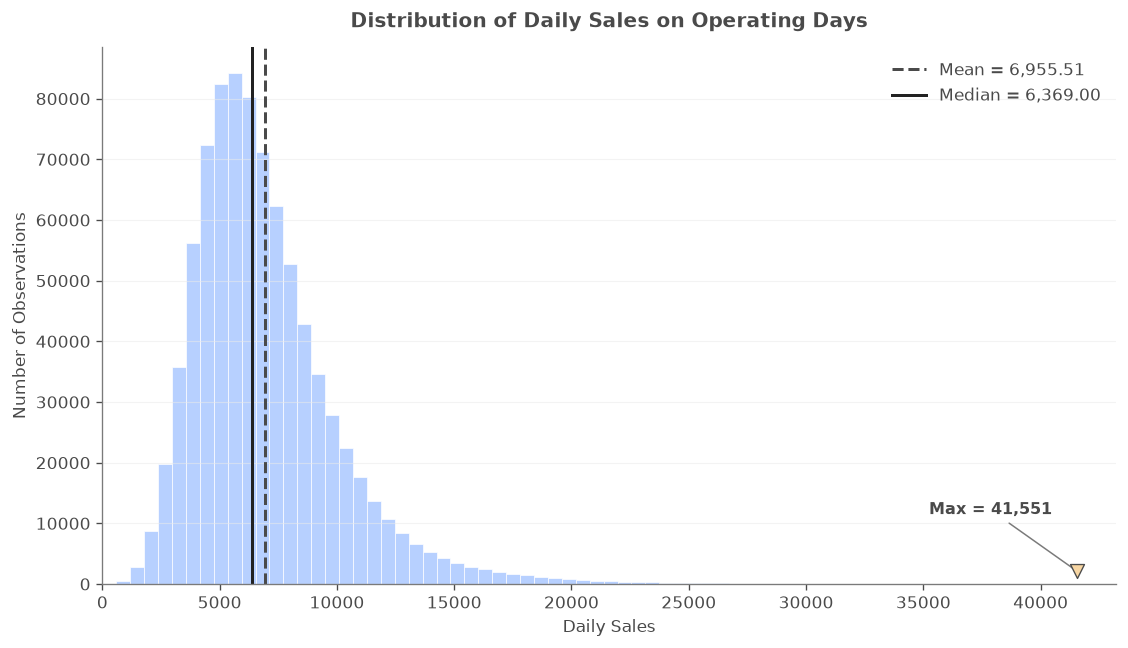

Figure saved to: d:\Coding\NTUHomeworks\AssignmentOfCA6000\outputs\figures\sales_distribution_open.png


In [4]:
# Visualize the distribution of Sales for operating days.

sales_open = (
    train_open["Sales"]
    .dropna()
)


# ------------------------------------------------------------
# 1. Retrieve reference statistics
# ------------------------------------------------------------

sales_mean = sales_open.mean()
sales_median = sales_open.median()
sales_max = sales_open.max()


# ------------------------------------------------------------
# 2. Create the histogram
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9.5, 5.5)
)

counts, bin_edges, patches = ax.hist(
    sales_open,
    bins=70,
    color=PASTEL_BLUE,
    edgecolor="white",
    linewidth=0.45,
    alpha=0.90
)


# ------------------------------------------------------------
# 3. Add mean and median reference lines
# ------------------------------------------------------------

ax.axvline(
    sales_mean,
    color=DARK_GREY,
    linestyle="--",
    linewidth=1.8,
    label=f"Mean = {sales_mean:,.2f}"
)

ax.axvline(
    sales_median,
    color="#222222",
    linestyle="-",
    linewidth=1.8,
    label=f"Median = {sales_median:,.2f}"
)


# ------------------------------------------------------------
# 4. Mark the maximum observed value
# ------------------------------------------------------------

histogram_peak = counts.max()

max_marker_y = (
    histogram_peak * 0.025
)

ax.scatter(
    sales_max,
    max_marker_y,
    marker="v",
    s=70,
    color=PASTEL_ORANGE,
    edgecolor=DARK_GREY,
    linewidth=0.8,
    zorder=5
)

ax.annotate(
    f"Max = {sales_max:,.0f}",
    xy=(
        sales_max,
        max_marker_y
    ),
    xytext=(-15, 32),
    textcoords="offset points",
    ha="right",
    va="bottom",
    color=DARK_GREY,
    fontsize=9.5,
    fontweight="bold",
    arrowprops={
        "arrowstyle": "-",
        "color": MID_GREY,
        "linewidth": 0.9
    }
)


# ------------------------------------------------------------
# 5. Format the figure
# ------------------------------------------------------------

ax.set_title(
    "Distribution of Daily Sales on Operating Days",
    pad=12,
    fontweight="bold"
)

ax.set_xlabel(
    "Daily Sales"
)

ax.set_ylabel(
    "Number of Observations"
)

# Explicitly show the complete observed Sales range.
ax.set_xlim(
    left=0,
    right=sales_max * 1.04
)

ax.ticklabel_format(
    style="plain",
    axis="y"
)

ax.legend(
    loc="upper right"
)

ax.grid(
    axis="x",
    visible=False
)

ax.grid(
    axis="y",
    alpha=0.55
)

fig.tight_layout()


# ------------------------------------------------------------
# 6. Save and display
# ------------------------------------------------------------

figure_path = (
    FIGURES_DIR
    / "sales_distribution_open.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Figure saved to: {figure_path}"
)

## 4. Boxplot Analysis of Operating-Day Sales

## Purpose

The histogram demonstrated that operating-day sales exhibit a long right tail.

A boxplot is further used to quantify the spread of Sales and identify observations beyond the conventional statistical outlier boundary.

Unlike the histogram, which focuses on the overall frequency distribution, the boxplot summarizes:

- median value;
- interquartile range;
- potential extreme observations.

## Input

The analysis uses:

- `train_open`

with:

- `Open = 1`

The variable analysed is:

- `Sales`

A total of **844,392** operating-day observations are included.

## Method

The boxplot is based on quartile statistics.

The interquartile range is defined as:

$$
IQR = Q_3-Q_1
$$

The lower and upper outlier boundaries are:

$$
Lower = Q_1-1.5\times IQR
$$

$$
Upper = Q_3+1.5\times IQR
$$

For operating-day Sales:

$$
Q_1=4,859
$$

$$
Q_3=8,360
$$

Therefore:

$$
IQR=8,360-4,859=3,501
$$

The upper boundary is:

$$
Upper=8,360+1.5\times3,501
$$

$$
=13,611.5
$$

Observations above this threshold are identified as statistical high-end outliers.

## Visualization Design

A pastel purple box is used to represent the central distribution.

Outlier observations are displayed with low-opacity markers because many high-sales observations exist. Reduced transparency prevents dense regions from visually dominating the figure.

Important statistics are represented using dark grey elements to maintain readability.

The full dataset range is retained. No observations are removed.

## Output

The figure is displayed in the notebook and saved as:

`outputs/figures/sales_boxplot_open.png`

## Evaluation

The boxplot is interpreted together with the histogram.

The main evaluation points are:

- whether the distribution has substantial asymmetry;
- the proportion of observations beyond the upper boundary;
- whether detected outliers represent errors or meaningful high-sales events.

Because the identified high-sales observations correspond to valid records, they are retained for subsequent modelling.

C:\Users\31729\AppData\Local\Temp\ipykernel_32120\1664490463.py:58: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


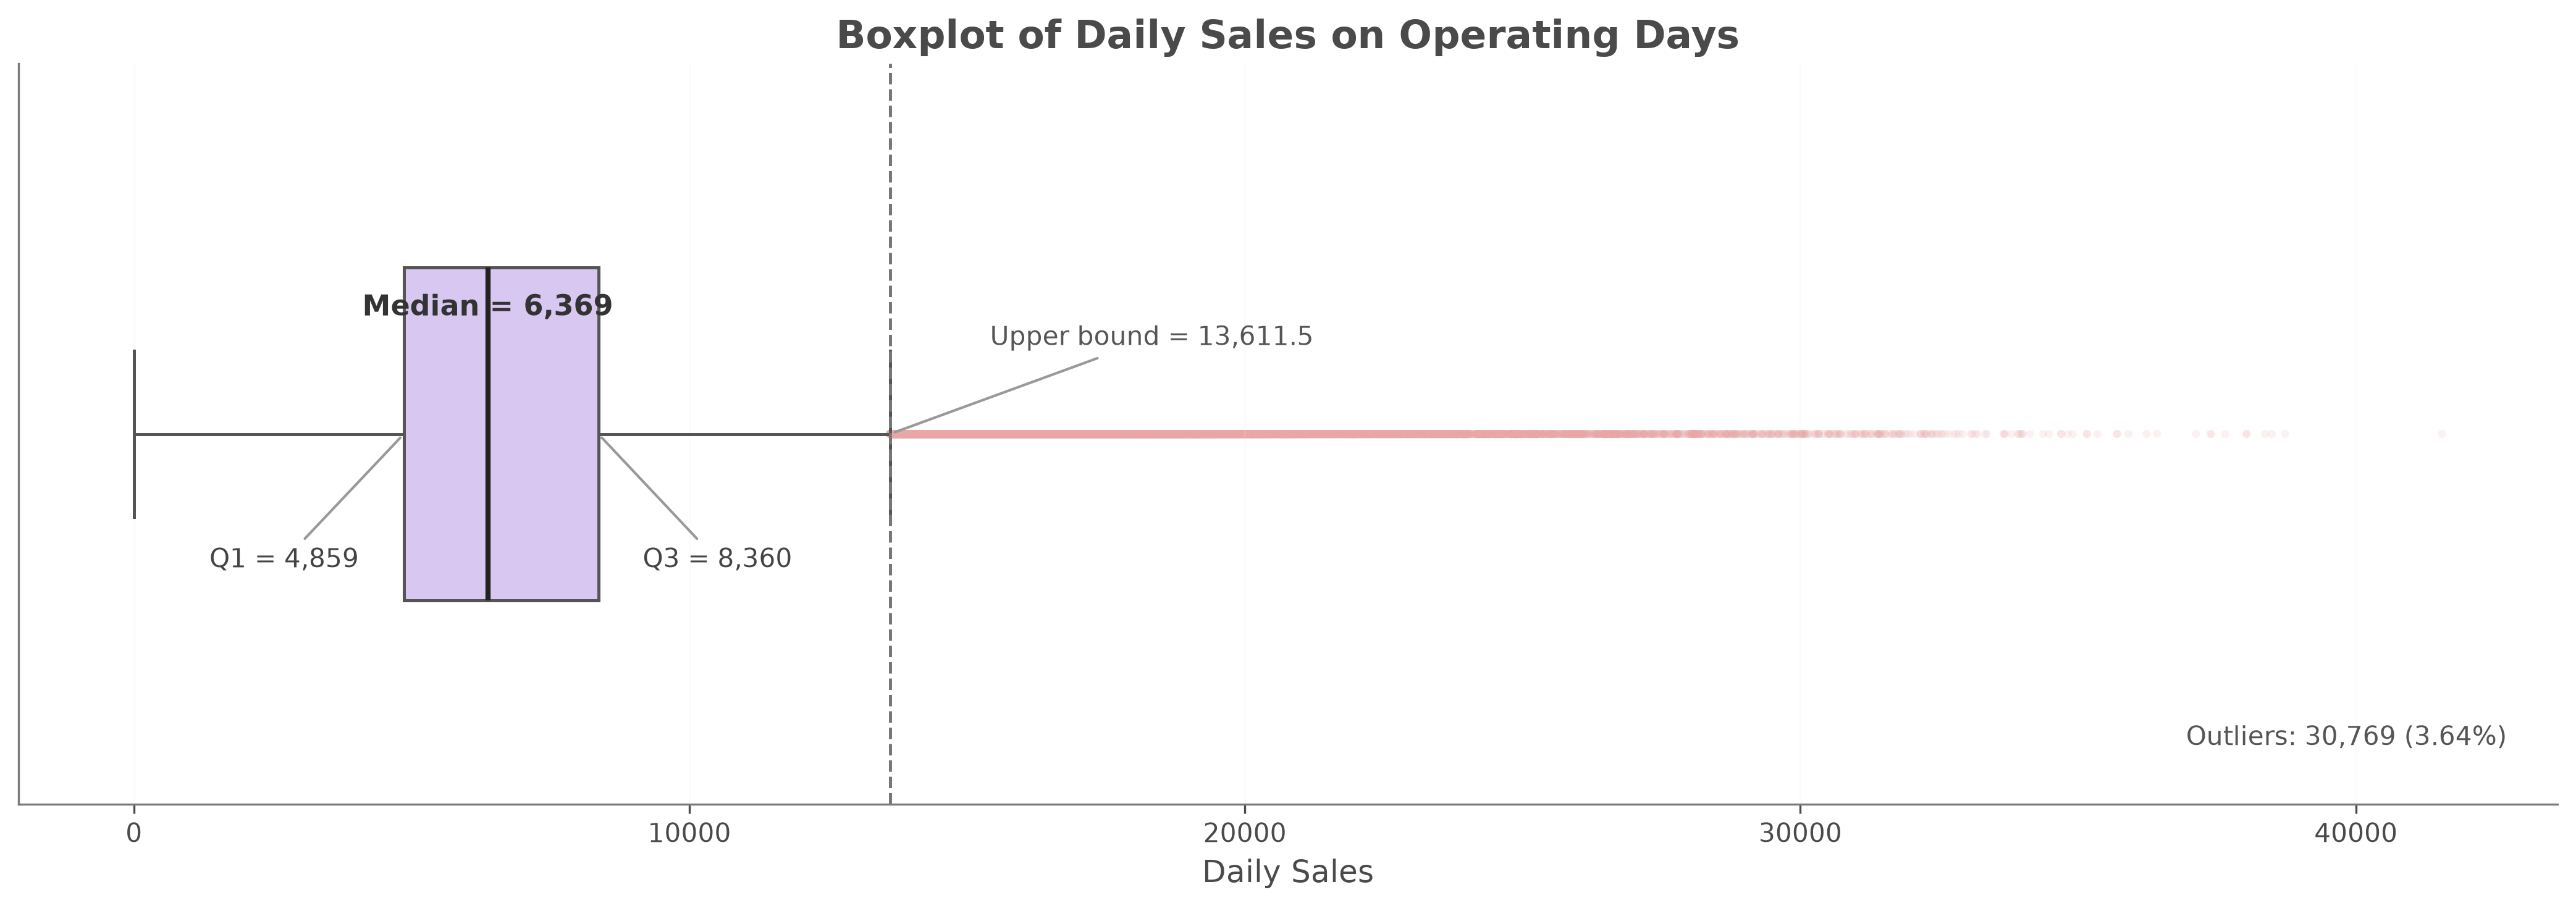

Q1: 4,859.00
Median: 6,369.00
Q3: 8,360.00
IQR: 3,501.00
Upper outlier boundary: 13,611.50
Outliers: 30,769 (3.64%)
Figure saved to: ../outputs/figures/sales_boxplot_open.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np


# =========================================
# Boxplot of Daily Sales on Operating Days
# =========================================


# Select operating days only
sales_open = train.loc[
    train["Open"] == 1,
    "Sales"
]


# =========================================
# Calculate statistics
# =========================================

q1 = sales_open.quantile(0.25)
median = sales_open.quantile(0.50)
q3 = sales_open.quantile(0.75)

iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr


# Outliers
outliers = sales_open[
    sales_open > upper_bound
]

outlier_count = len(outliers)

outlier_percentage = (
    outlier_count / len(sales_open) * 100
)



# =========================================
# Create figure
# =========================================

plt.figure(
    figsize=(14, 5),
    dpi=300
)



# =========================================
# Main boxplot
# =========================================

plt.boxplot(
    sales_open,
    vert=False,
    patch_artist=True,
    widths=0.45,
    showfliers=False,

    boxprops={
        "facecolor": "#D8C7F0",
        "edgecolor": "#555555",
        "linewidth": 1.2
    },

    medianprops={
        "color": "#222222",
        "linewidth": 2
    },

    whiskerprops={
        "color": "#555555",
        "linewidth": 1.2
    },

    capprops={
        "color": "#555555",
        "linewidth": 1.2
    }
)



# =========================================
# Plot outliers
# =========================================

plt.scatter(
    outliers,
    np.ones(len(outliers)),
    s=10,
    color="#E8A6A6",
    alpha=0.15,
    edgecolors="none"
)



# =========================================
# Annotation
# =========================================


# Median
plt.text(
    median,
    1.16,
    f"Median = {median:,.0f}",
    ha="center",
    fontsize=11,
    fontweight="bold",
    color="#333333"
)



# Q1
plt.annotate(
    f"Q1 = {q1:,.0f}",
    xy=(q1, 1),
    xytext=(q1-3500, 0.82),

    fontsize=10,
    color="#444444",

    arrowprops={
        "arrowstyle": "-",
        "color": "#999999"
    }
)



# Q3
plt.annotate(
    f"Q3 = {q3:,.0f}",
    xy=(q3, 1),
    xytext=(q3+800, 0.82),

    fontsize=10,
    color="#444444",

    arrowprops={
        "arrowstyle": "-",
        "color": "#999999"
    }
)



# Upper outlier boundary

plt.axvline(
    upper_bound,
    linestyle="--",
    linewidth=1.2,
    color="#777777"
)


plt.annotate(
    f"Upper bound = {upper_bound:,.1f}",

    xy=(upper_bound, 1),

    xytext=(
        upper_bound + 1800,
        1.12
    ),

    fontsize=10,
    color="#555555",

    arrowprops={
        "arrowstyle": "-",
        "color": "#999999"
    }
)



# Outlier summary

plt.text(
    0.98,
    0.08,

    f"Outliers: {outlier_count:,} "
    f"({outlier_percentage:.2f}%)",

    transform=plt.gca().transAxes,

    ha="right",

    fontsize=10,

    color="#555555"
)



# =========================================
# Style
# =========================================


plt.title(
    "Boxplot of Daily Sales on Operating Days",

    fontsize=15,

    fontweight="bold"
)


plt.xlabel(
    "Daily Sales",

    fontsize=12
)


plt.yticks([])


plt.grid(
    axis="x",
    alpha=0.15
)


plt.tight_layout()



# =========================================
# Save
# =========================================

output_path = (
    "../outputs/figures/"
    "sales_boxplot_open.png"
)


plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()



# =========================================
# Audit output
# =========================================

print(f"Q1: {q1:,.2f}")
print(f"Median: {median:,.2f}")
print(f"Q3: {q3:,.2f}")
print(f"IQR: {iqr:,.2f}")
print(f"Upper outlier boundary: {upper_bound:,.2f}")

print(
    f"Outliers: {outlier_count:,} "
    f"({outlier_percentage:.2f}%)"
)

print(
    f"Figure saved to: {output_path}"
)